In [134]:
import matplotlib.pyplot as plt
import pandas as pd

import colorcet as cc

In [2]:
filepath = 'data/IOM_DTM_ETT_SOM_Tracker_sinceFeb2025_w19.xlsx'

In [5]:
df = pd.read_excel(filepath)

In [7]:
df.head(3)

,Date of Assessment,Region Name,District Name,OCHA Region Pcode,OCHA District Pcode,Operational Zone,Catchment,Settlement Name,Settlement ID,Location Type,...,Needs - Temporary Learning Classes,Needs - CCCM Site improvement,Needs - CCCM Complaints and Feedback Mechanism,Needs - CCCM Site Decongestion,Needs - CCCM Plot Allocation,Data Collection Week,Origin_Destination,Origin_Region_country,Origin_District_country,Reason of Displacement
0,2025-06-16,Galgaduud,Cabudwaaq,SO19,SO1902,OPZ 211,NaN,Canjiidle,DTM-SO1902-12769,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OC,Ethiopia,Ethiopia,Drought
1,2025-06-14,Bay,Baidoa,SO24,SO2401,OPZ 179,CA02,Wadajir 6 Jinaay,DTM-SO2401-11287,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Bakool,Waajid,Drought
2,2025-06-14,Galgaduud,Dhuusamarreeb,SO19,SO1901,OPZ 226,NaN,Dalab,DTM-SO1901-6596,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Hiraan,Bulo Burto,Drought


In [10]:
for column in df.columns:
    print(column)

Date of Assessment
Region Name
District Name
OCHA Region Pcode
OCHA District Pcode
Operational Zone
Catchment
Settlement Name
Settlement ID
Location Type
Settlement Classification
Neighborhood
Main Cause of Displacement
Main Cause of Displacement (type of conflict)
Main Cause of Displacement (type of Natural hazard)
New arrivals since last week
Total new arrivals since last week
Number of Males (18 and above) since last week
Number of Females (18 and above) since last week
Number of Children under 18 since last week
Departures since last week
Total number of departures since last week
What is the reason for majority of the departees to leave this settlement?
What is the destination of the majority of the departees?
Region of destination for majority of departees
District of destination for majority of departees
Reason for the new arrivals to come to this location
Final destination of the new arrivals
If yes, how long does the majority intend to stay
Date when the new arrivals left thei

# Preprocessing

## Timestamp column

In [20]:
cat = pd.Categorical(df['Data Collection Week'])

In [23]:
cat.categories.to_series().reset_index(drop=True)

0          Week 01 (8-12 February, 2025)
1         Week 02 (15-19 February, 2025)
2         Week 03 (22-26 February, 2025)
3              Week 04 (1-5 March, 2025)
4             Week 05 (8-12 March, 2025)
5            Week 06 (15-19 March, 2025)
6            Week 07 (22-26 March, 2025)
7     Week 08 (29 March - 2 April, 2025)
8            Week 09 (5 - 9 April, 2025)
9          Week 10 (12 - 16 April, 2025)
10         Week 11 (19 - 23 April, 2025)
11         Week 12 (26 - 30 April, 2025)
12             Week 13 (3 - 7 May, 2025)
13           Week 14 (10 - 14 May, 2025)
14           Week 15 (17 - 21 May, 2025)
15           Week 16 (24 - 28 May, 2025)
16      Week 17 (31 May - 04 June, 2025)
17           Week 18 (8 - 11 June, 2025)
18          Week 19 (14 - 18 June, 2025)
dtype: object

In [24]:
cat.codes

array([18, 18, 18, ...,  0,  0,  0], dtype=int8)

In [26]:
df['timestamp'] = cat.codes

# Analysis

## Number of IDPs

In [136]:
def plot_agg(df, feature):
    table = df.groupby(['District Name', 'Data Collection Week'], observed=False)[feature].sum().unstack().T

    colours = cc.glasbey[:table.columns.shape[0]]
    
    fig, ax = plt.subplots(1, figsize=(13,13))

    for column, colour in zip(table.columns, colours):
        col = table[column]
        ax.scatter(col.index, col, s=7, c=colour)
        ax.plot(col.index, col, linestyle='--', linewidth=1, label=column, color=colour)
    
    ax.set_xticks(range(col.index.shape[0]), labels=col.index, rotation=90)
    
    ax.set_ylabel(feature)
    ax.set_xlabel('Data Collection Week')
    
    #ax.set_yscale('log')
    ax.grid('on', alpha=.3)

    fig.legend()
    return table

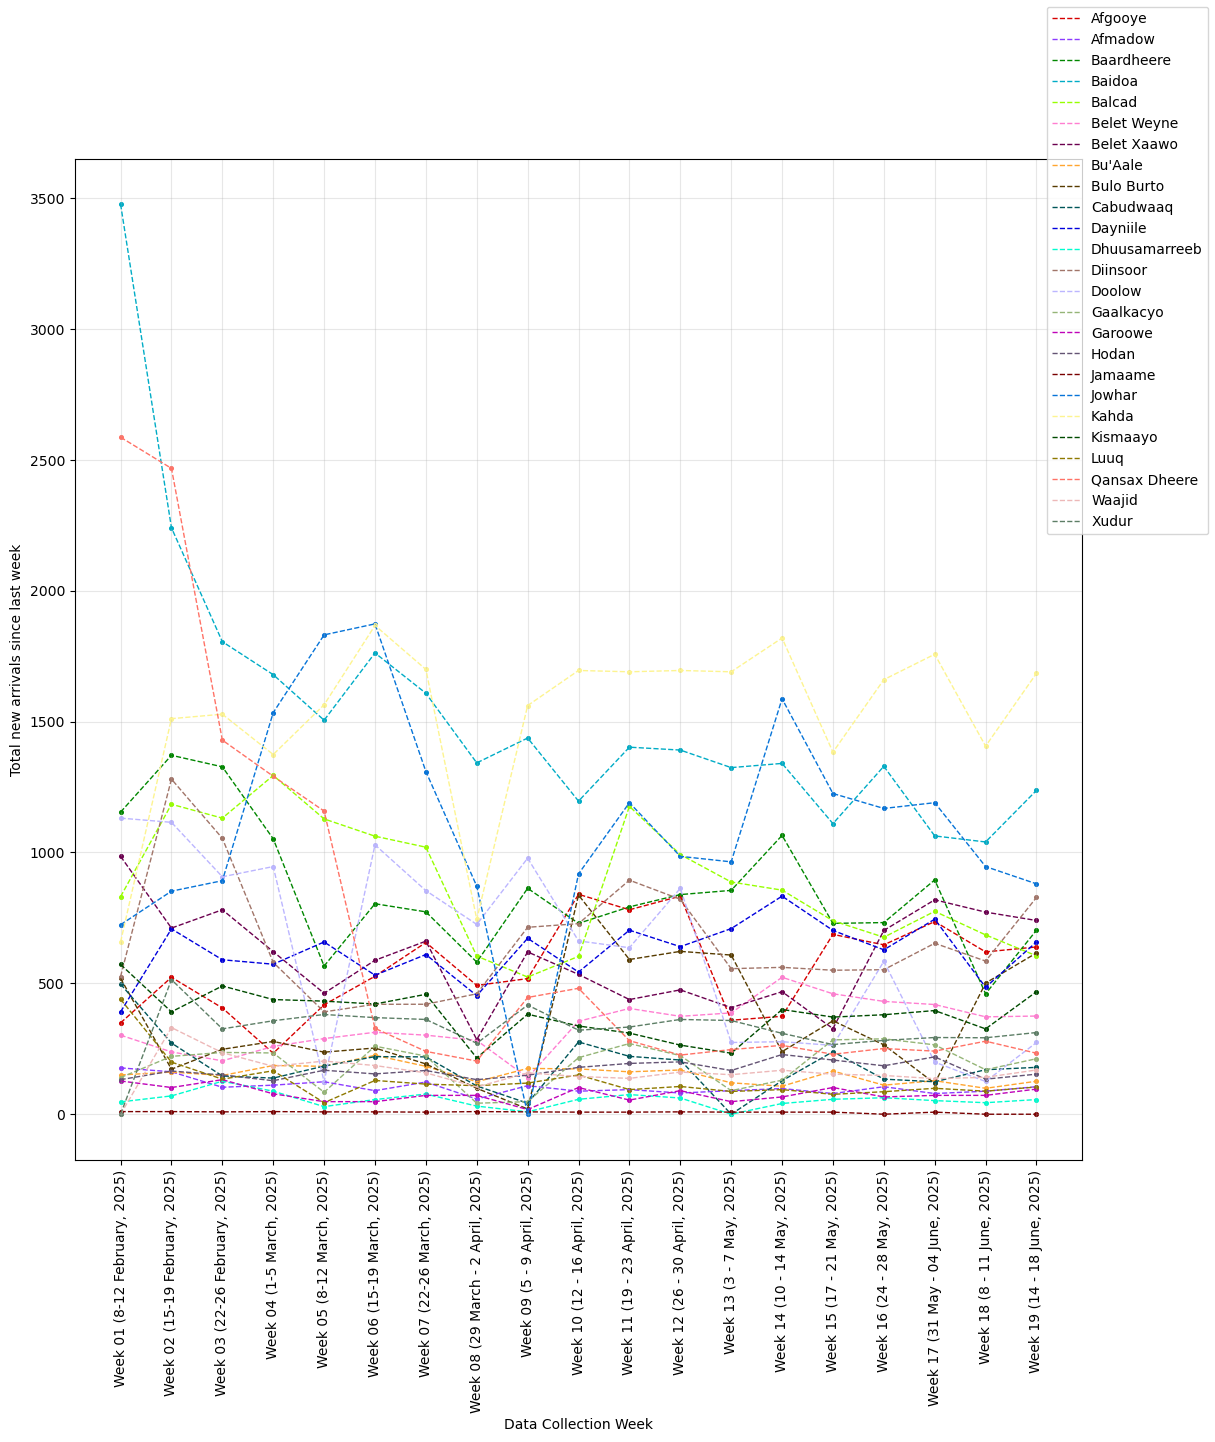

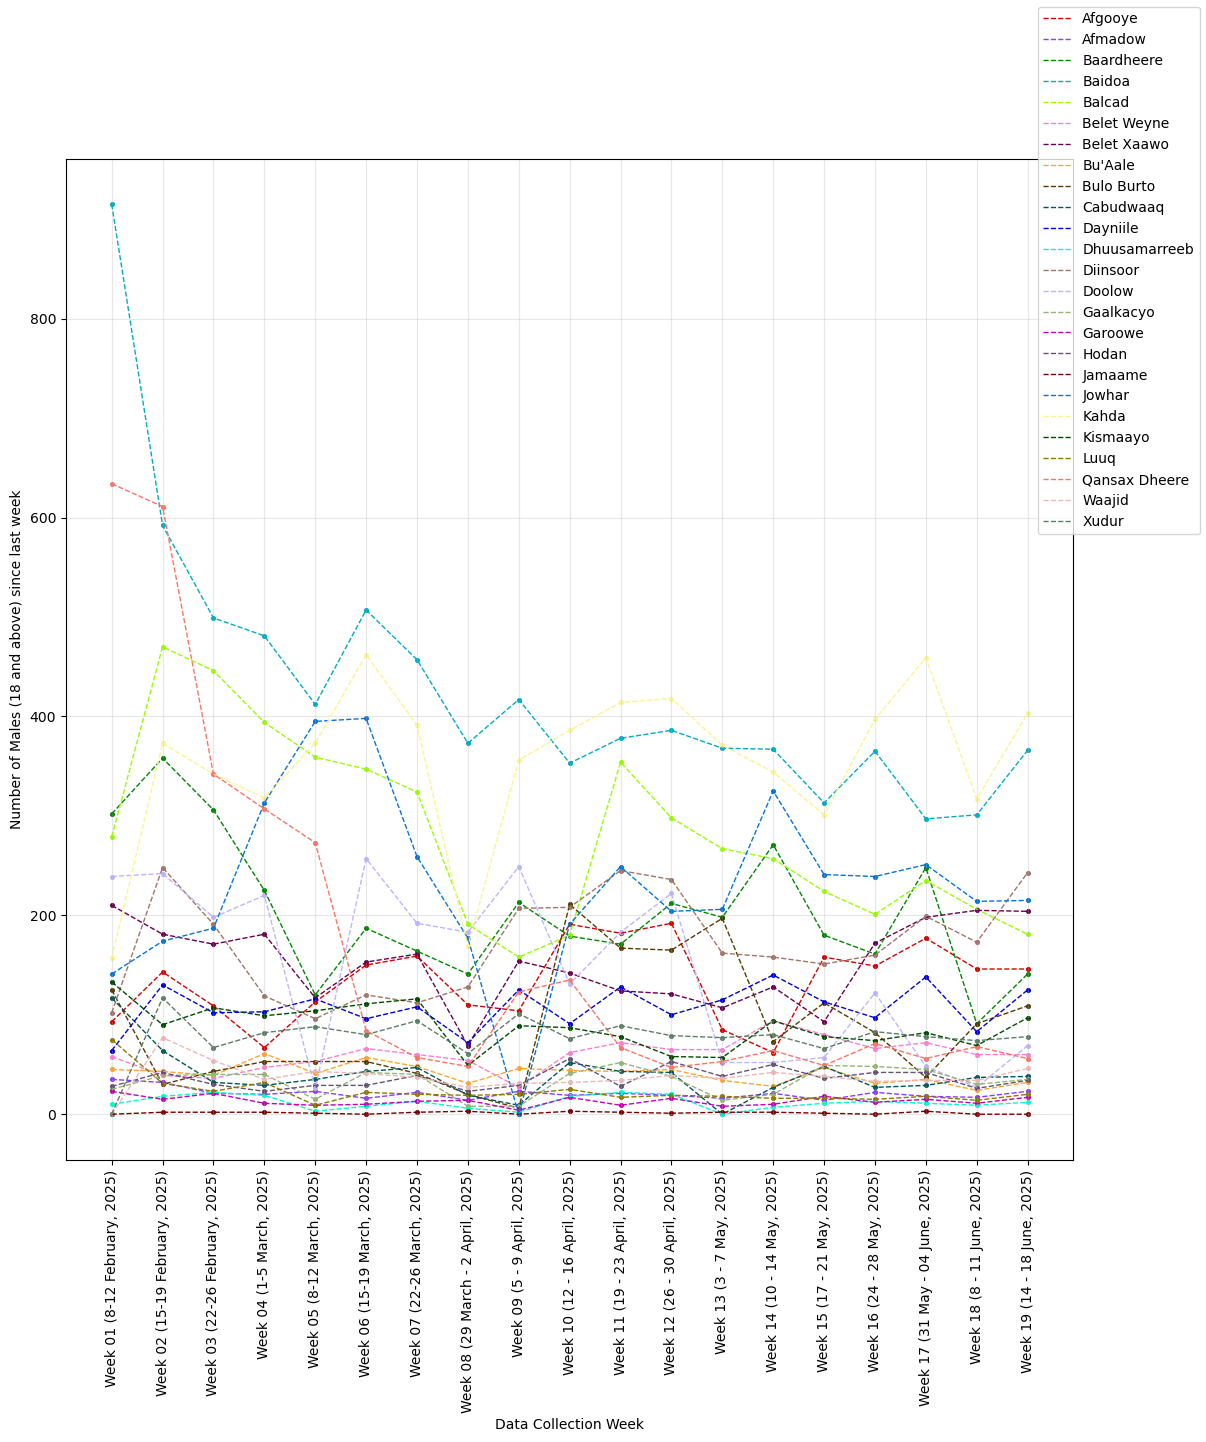

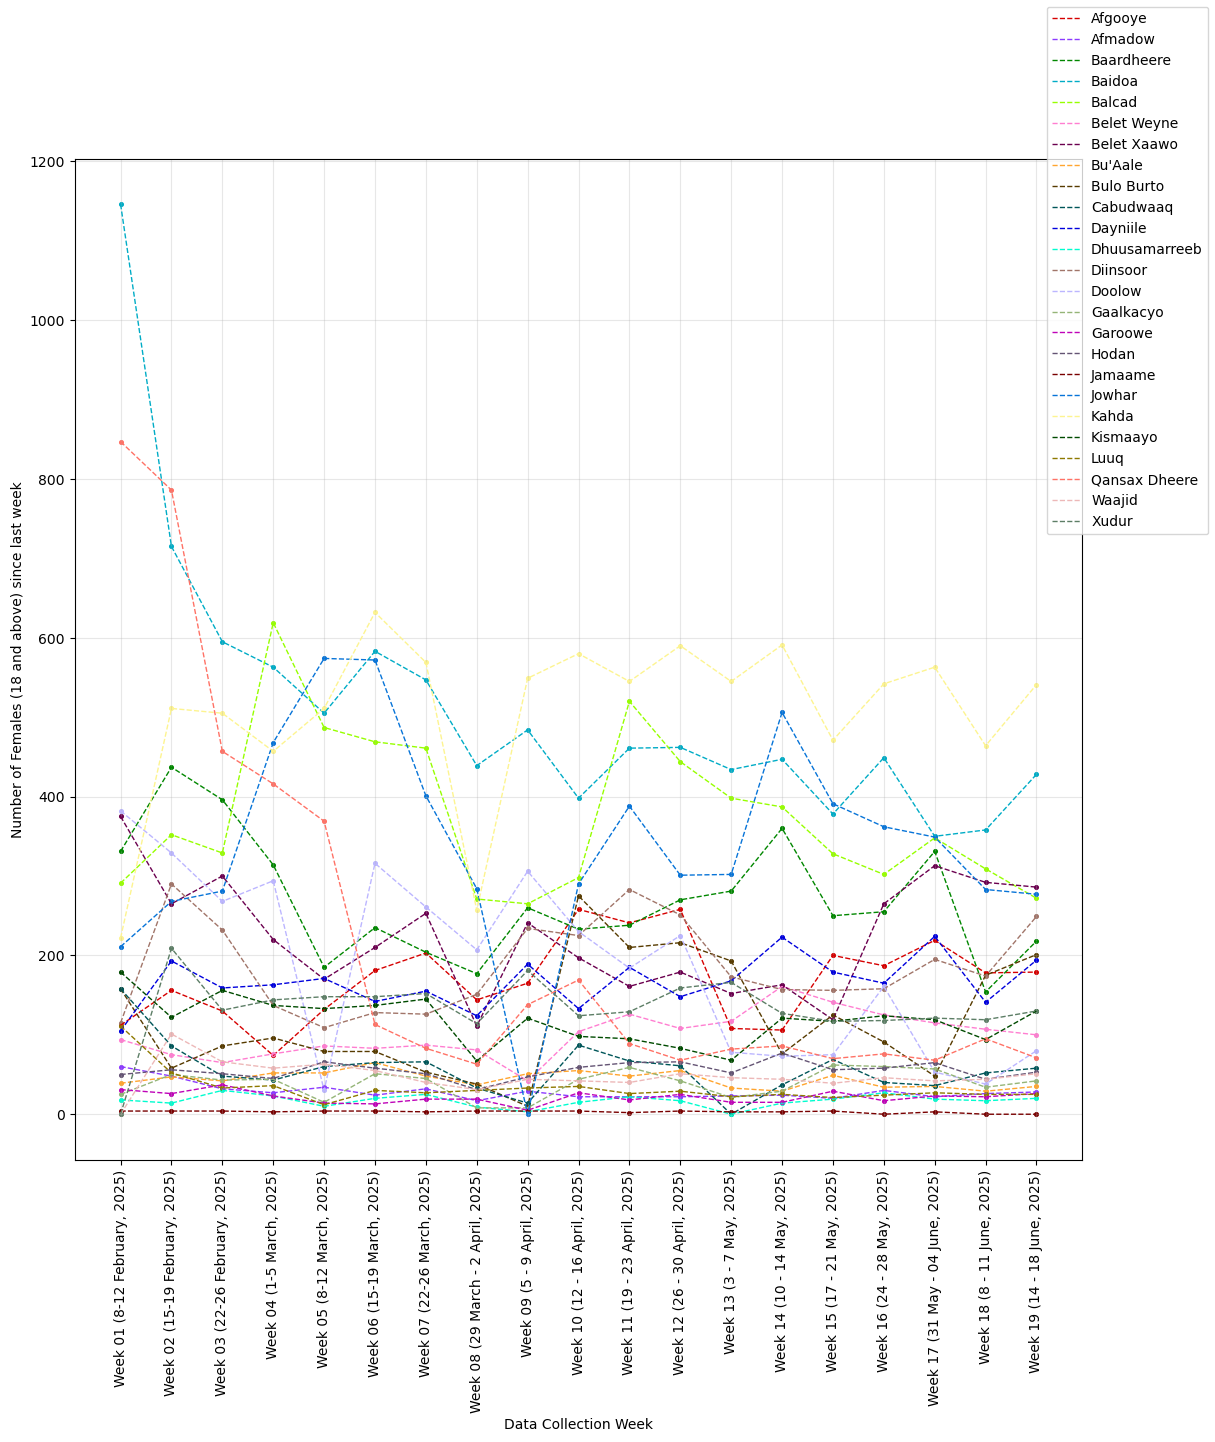

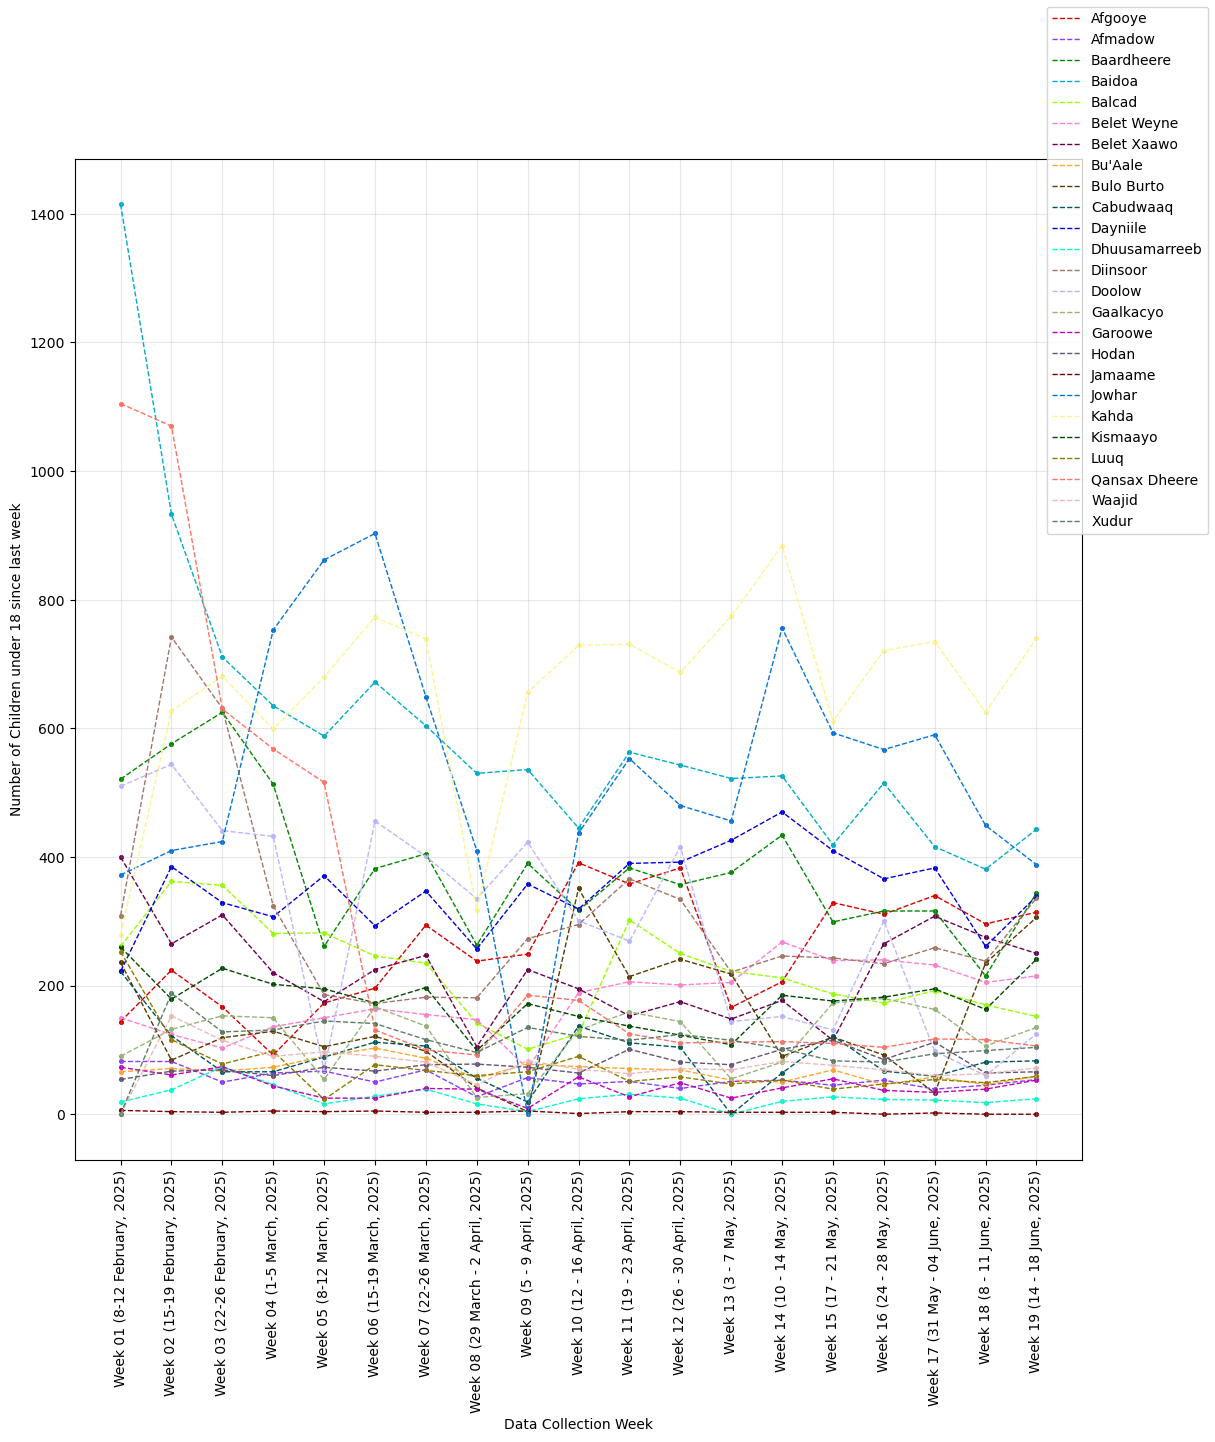

In [137]:
for feature in (
    'Total new arrivals since last week',
    'Number of Males (18 and above) since last week',
    'Number of Females (18 and above) since last week',
    'Number of Children under 18 since last week',
):
    table = plot_agg(df, feature)
    # display(table)

## Reason for displacement

In [70]:
df['Main Cause of Displacement']

0        Natural Hazards
1        Natural Hazards
2        Natural Hazards
3        Natural Hazards
4        Natural Hazards
              ...       
20215           Conflict
20216    Natural Hazards
20217    Natural Hazards
20218           Conflict
20219    Natural Hazards
Name: Main Cause of Displacement, Length: 20220, dtype: object

In [142]:
table = df.groupby(['District Name', 'Data Collection Week'], observed=False)['Main Cause of Displacement'].value_counts(dropna=False).unstack().sort_index()
table = table.stack().swaplevel(0,2).swaplevel(1,2).unstack().T

In [143]:
table

Main Cause of Displacement         Conflict                                   \
District Name                       Afgooye Afmadow Baardheere Baidoa Balcad   
Data Collection Week                                                           
Week 01 (8-12 February, 2025)            23       7         29     14      0   
Week 02 (15-19 February, 2025)           33      11         29      5      0   
Week 03 (22-26 February, 2025)           39       7         28     24      0   
Week 04 (1-5 March, 2025)                30       8         25     32      0   
Week 05 (8-12 March, 2025)               32      12         12     21      0   
Week 06 (15-19 March, 2025)              34      11         20     32     17   
Week 07 (22-26 March, 2025)              32      11         27     21     17   
Week 08 (29 March - 2 April, 2025)       26       3         15     31      6   
Week 09 (5 - 9 April, 2025)              24      11         29     23     12   
Week 10 (12 - 16 April, 2025)            38      12         24     19      5   
Week 11 (19 - 23 April, 2025)            41      13         24     16     18   
Week 12 (26 - 30 April, 2025)            43      10         24     15     18   
Week 13 (3 - 7 May, 2025)                22      12         24     26     20   
Week 14 (10 - 14 May, 2025)              21      12         30     16     19   
Week 15 (17 - 21 May, 2025)              11      11         24     15     24   
Week 16 (24 - 28 May, 2025)              20      12         24     19     20   
Week 17 (31 May - 04 June, 2025)         41      12         24     11     21   
Week 18 (8 - 11 June, 2025)              36      11         16     16     14   
Week 19 (14 - 18 June, 2025)             33      12         24     26     19   

Main Cause of Displacement                                                     \
District Name                      Belet Weyne Belet Xaawo Bu'Aale Bulo Burto   
Data Collection Week                                                            
Week 01 (8-12 February, 2025)                2           0       6          4   
Week 02 (15-19 February, 2025)               4           0       7          1   
Week 03 (22-26 February, 2025)               4           0       6          1   
Week 04 (1-5 March, 2025)                    5           0       7          1   
Week 05 (8-12 March, 2025)                   4           0       6          1   
Week 06 (15-19 March, 2025)                  4           0       7          2   
Week 07 (22-26 March, 2025)                  5           0      12          0   
Week 08 (29 March - 2 April, 2025)           4           0       7          0   
Week 09 (5 - 9 April, 2025)                  3           0       5          0   
Week 10 (12 - 16 April, 2025)                5           0       8          6   
Week 11 (19 - 23 April, 2025)               13           0       9          6   
Week 12 (26 - 30 April, 2025)                4           0       7         10   
Week 13 (3 - 7 May, 2025)                    6           0       9          5   
Week 14 (10 - 14 May, 2025)                  8           0      12          0   
Week 15 (17 - 21 May, 2025)                  5           0      16          5   
Week 16 (24 - 28 May, 2025)                  6           0      17          6   
Week 17 (31 May - 04 June, 2025)             1           0      18          0   
Week 18 (8 - 11 June, 2025)                  1           0      12          6   
Week 19 (14 - 18 June, 2025)                 0           0      18          7   

Main Cause of Displacement                    ...   Other                \
District Name                      Cabudwaaq  ... Garoowe Hodan Jamaame   
Data Collection Week                          ...                         
Week 01 (8-12 February, 2025)              5  ...       0     0       0   
Week 02 (15-19 February, 2025)             3  ...       0     0       0   
Week 03 (22-26 February, 2025)             1  ...       0     0       0   
Week 0

In [145]:
colours

['#d60000',
 '#8c3bff',
 '#018700',
 '#00acc6',
 '#97ff00',
 '#ff7ed1',
 '#6b004f',
 '#ffa52f',
 '#573b00',
 '#005659',
 '#0000dd',
 '#00fdcf',
 '#a17569',
 '#bcb6ff',
 '#95b577',
 '#bf03b8',
 '#645474',
 '#790000',
 '#0774d8',
 '#fdf490',
 '#004b00',
 '#8e7900',
 '#ff7266',
 '#edb8b8',
 '#5d7e66',
 '#9ae4ff',
 '#eb0077',
 '#a57bb8',
 '#5900a3',
 '#03c600',
 '#9e4b00',
 '#9c3b4f',
 '#cac300',
 '#708297',
 '#00af89',
 '#8287ff',
 '#5d363b',
 '#380000',
 '#fdbfff',
 '#bde6bf',
 '#db6d01',
 '#93b8b5',
 '#e452ff',
 '#2f5282',
 '#c36690',
 '#54621f',
 '#c49e72',
 '#038287',
 '#69e680',
 '#802690',
 '#6db3ff',
 '#4d33ff',
 '#85a301',
 '#fd03ca',
 '#c1a5c4',
 '#c45646',
 '#75573d',
 '#016742',
 '#00d6d4',
 '#dadfff',
 '#f9ff00',
 '#6967af',
 '#c39700',
 '#e1cd9c',
 '#da95ff',
 '#ba03fd',
 '#915282',
 '#a00072',
 '#569a54',
 '#d38c8e',
 '#364426',
 '#97a5c3',
 '#8e8c5e',
 '#ff4600',
 '#c8fff9',
 '#ae6dff',
 '#6ecfa7',
 '#bfff8c',
 '#8c54b1',
 '#773618',
 '#ffa079',
 '#a8001f',
 '#ff1c44',
 '#5

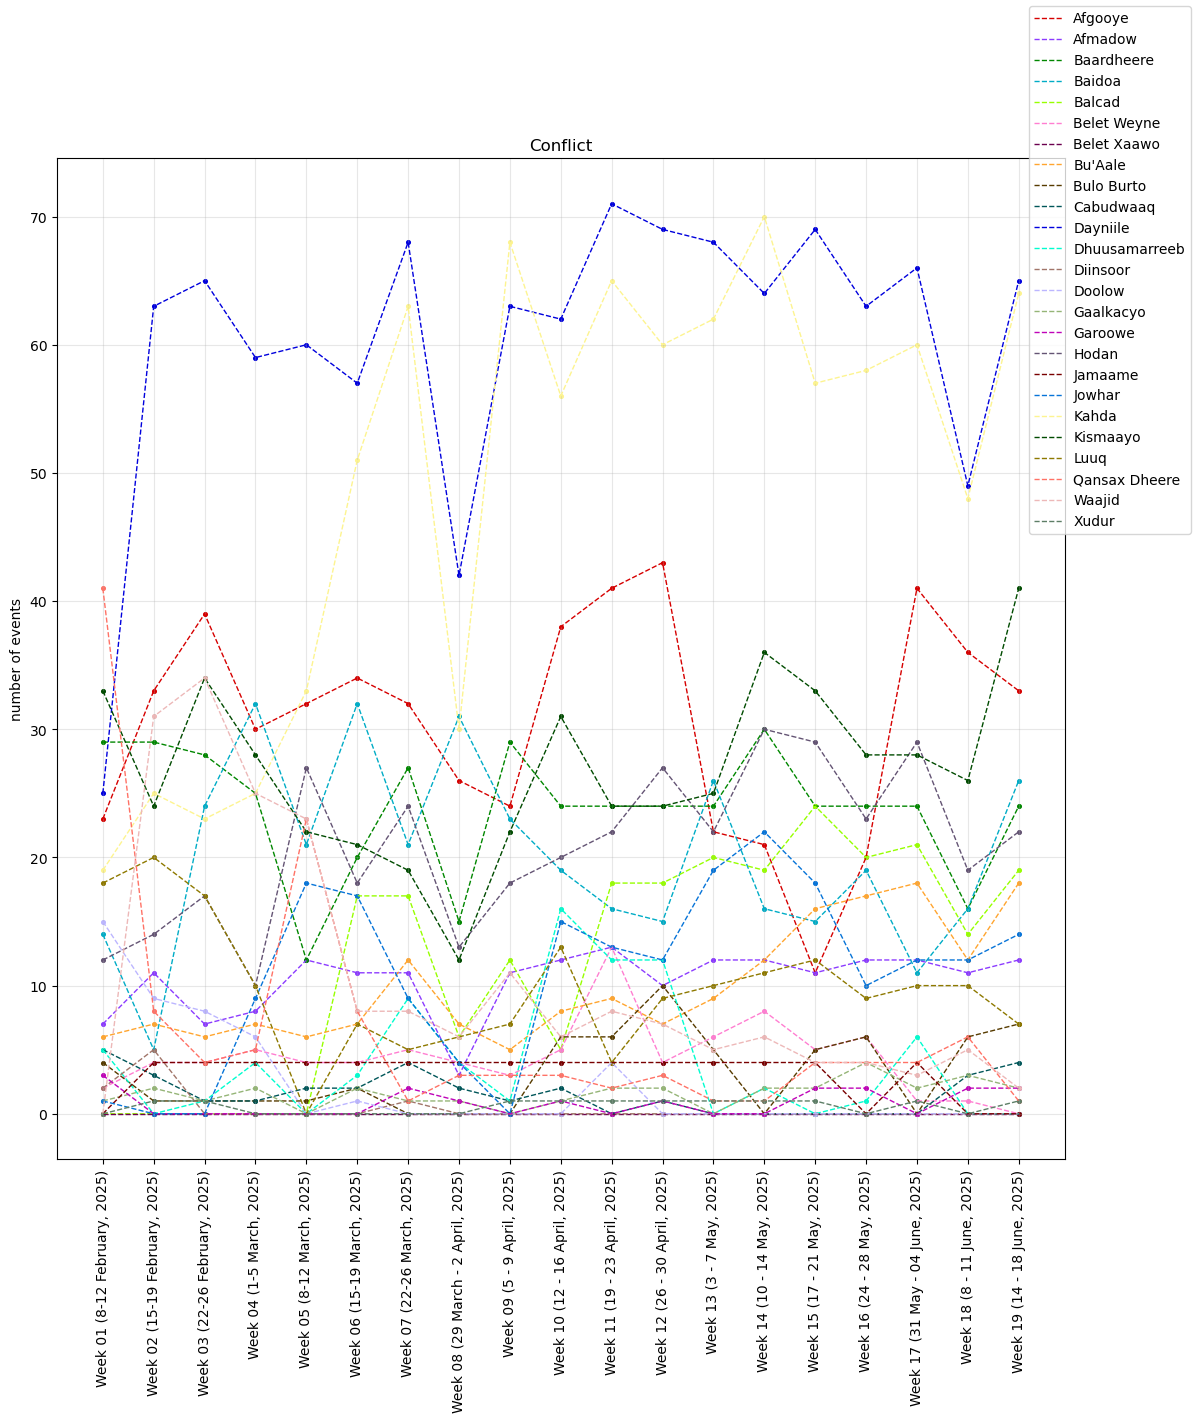

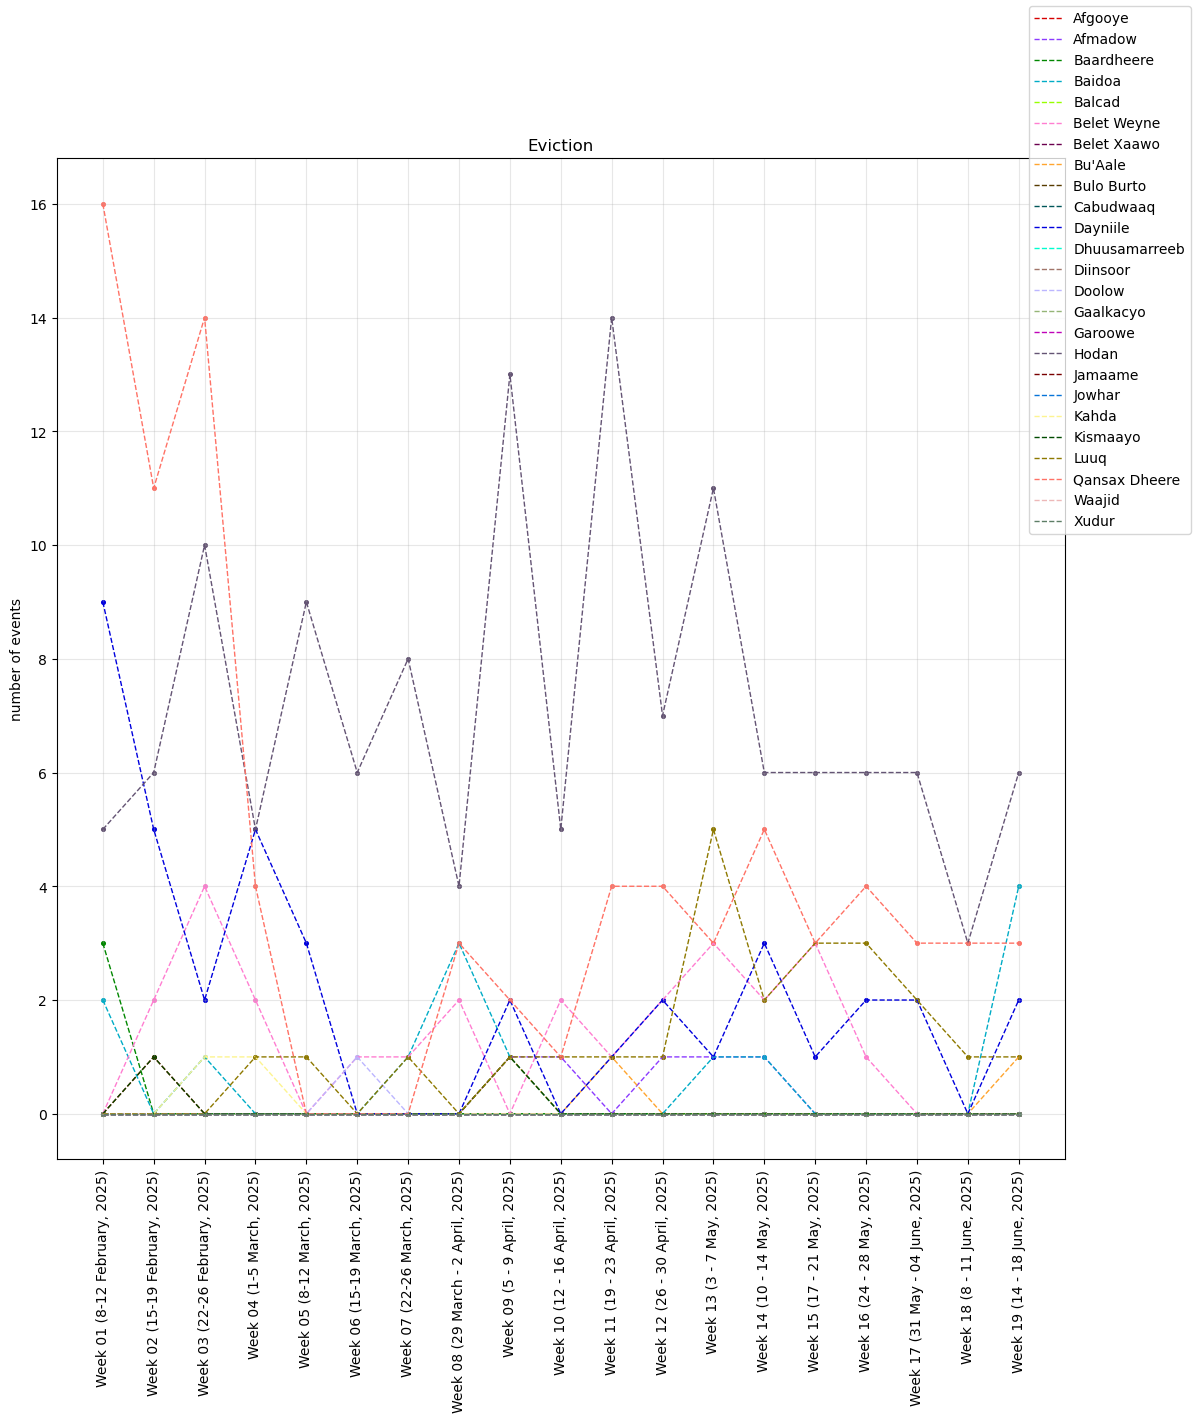

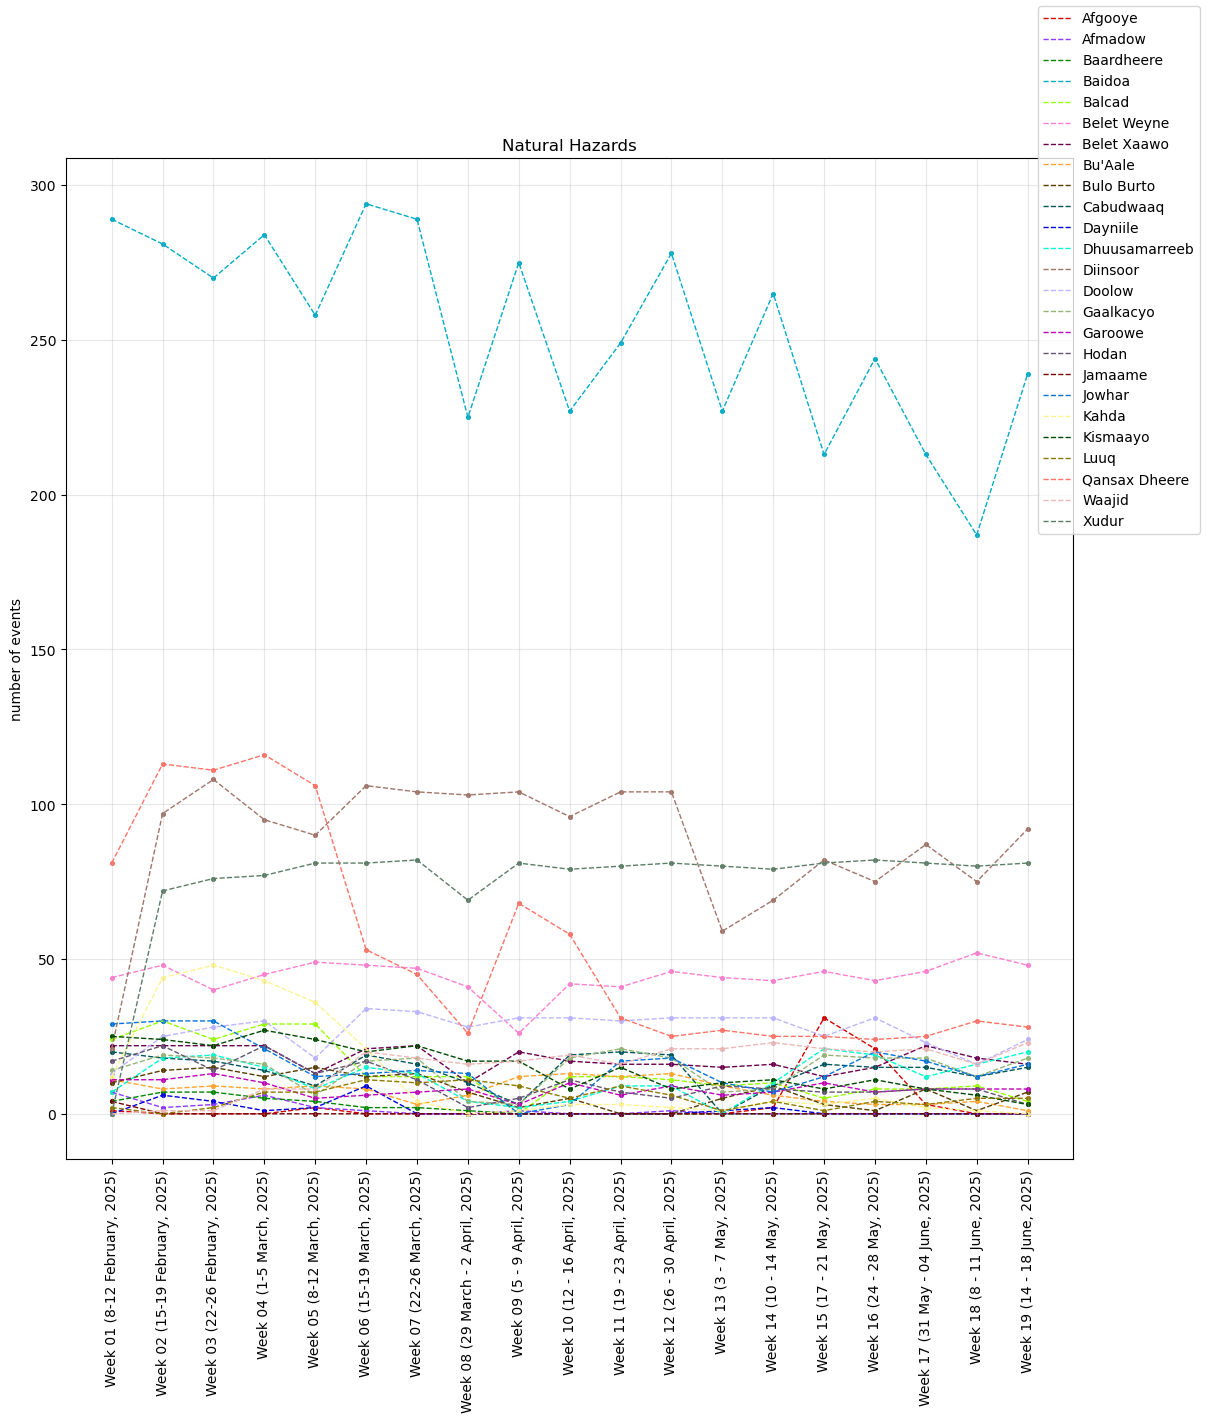

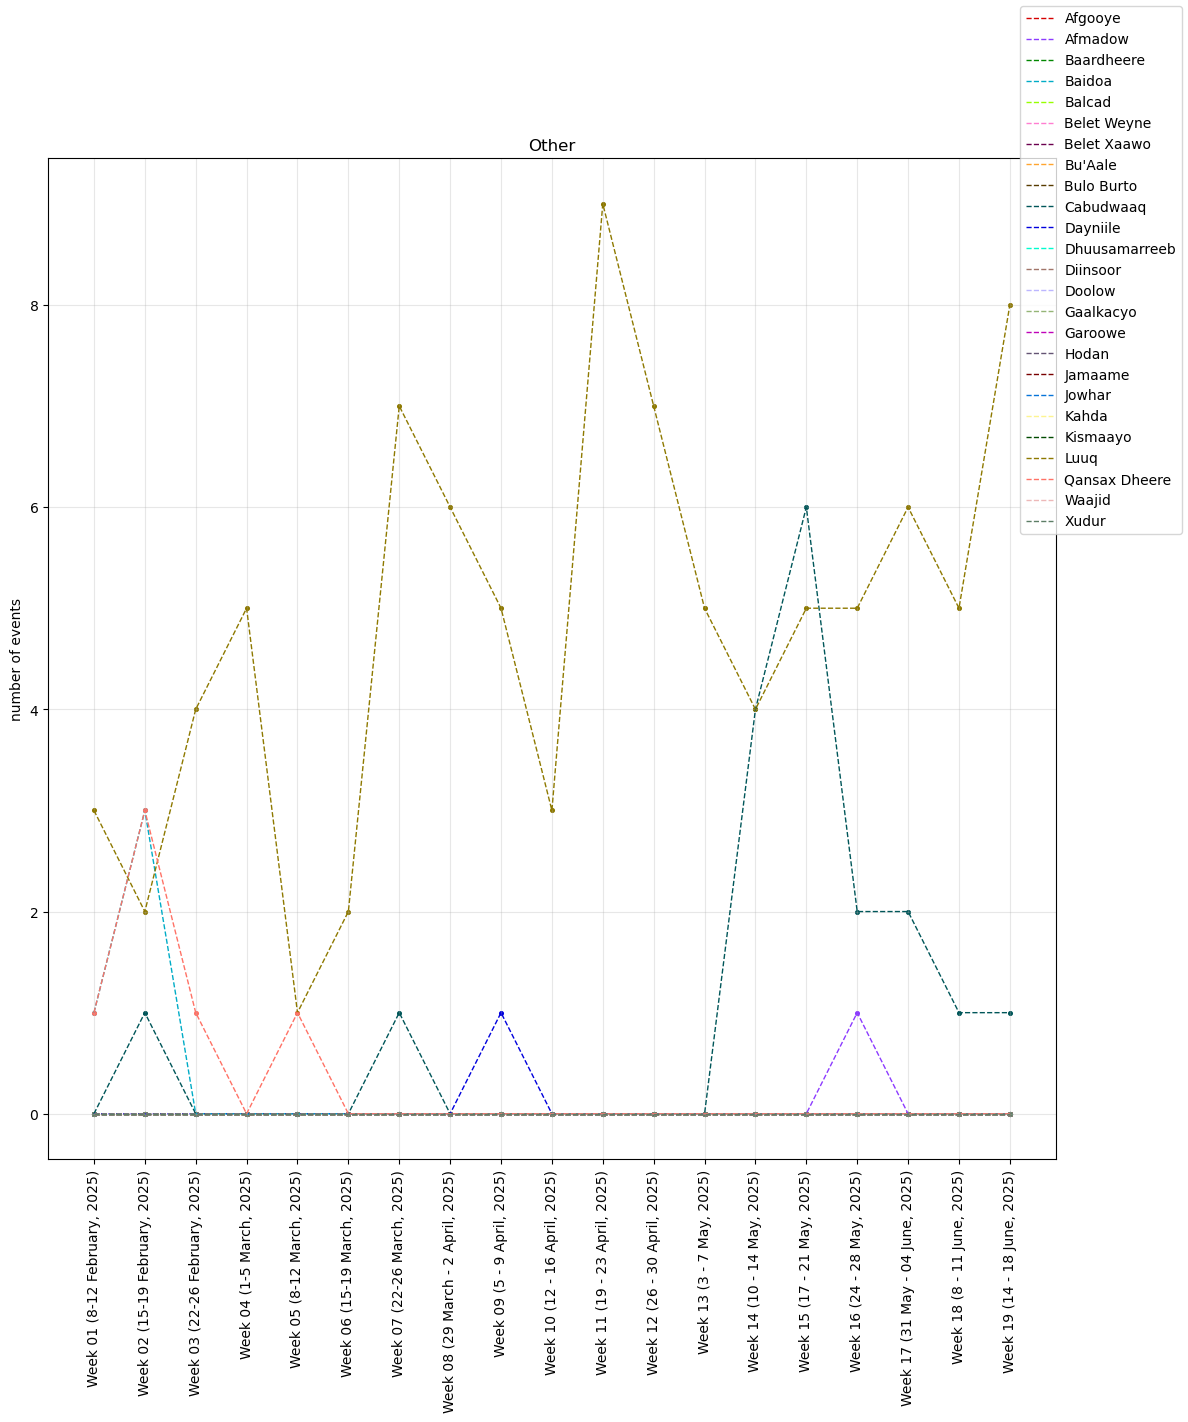

In [146]:
colours = cc.glasbey[:table.columns.shape[0]]

for column in table.columns.get_level_values(0).unique():
    sub = table[column]
    
    fig, ax = plt.subplots(1, figsize=(13,13))
    
    for c, colour in zip(sub.columns, colours):
        subb = sub[c]
        ax.scatter(subb.index, subb, s=7, c=colour)
        ax.plot(subb.index, subb, label=c, linestyle='--', linewidth=1, color=colour)

    ax.set_xticks(range(sub.shape[0]), labels=sub.index, rotation=90)

    ax.set_ylabel('number of events')
        
    ax.set_title(column)

    fig.legend()


    #ax.set_yscale('log')
    ax.grid('on', alpha=.3)